<a href="https://colab.research.google.com/github/yejinPARK48/michigan_building_detection/blob/main/Phase1_2_batch_A2_Oakland.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 & 2: Michigan Tile Generation — Batch A-2 (Oakland Only)
**County: Oakland (26125) — High-density urban county, run separately due to large footprint volume (~520K)**

Run this after Batch A has completed the other 6 counties.
Outputs accumulate into the same shared Drive folder.


## 0. Installation

In [ ]:
import os
os.environ['GDAL_HTTP_MAX_RETRY'] = '5'
os.environ['GDAL_HTTP_RETRY_DELAY'] = '1'

In [ ]:
!pip install pystac-client planetary-computer rasterio geopandas shapely pyogrio -q
!pip install segmentation-models-pytorch albumentations -q
!pip install opencv-python-headless scikit-image -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.1 MB/s eta 0:00:00


## 0-1. Import & Config

In [ ]:
import os, time, zipfile, urllib.request, warnings, shutil, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import cv2
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from shapely.geometry import box, mapping
from skimage import measure

import rasterio
from rasterio.features import rasterize
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.warp import transform_bounds
import pystac_client
import planetary_computer as pc

from google.colab import drive
drive.mount('/content/drive')

# ── Paths (shared across all batch files — outputs accumulate together) ────
BASE_DIR      = '/content/drive/MyDrive/michigan_unet_project'
TILE_IMG_DIR  = f'{BASE_DIR}/tiles/images'
TILE_MASK_DIR = f'{BASE_DIR}/tiles/masks'
META_DIR      = f'{BASE_DIR}/metadata'

FAST_BASE     = '/content/michigan_tiles_fast'
FAST_IMG_DIR  = f'{FAST_BASE}/images'
FAST_MASK_DIR = f'{FAST_BASE}/masks'

for d in [TILE_IMG_DIR, TILE_MASK_DIR, META_DIR, FAST_IMG_DIR, FAST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Tile Configuration ─────────────────────────────────────────────────────
TILE_SIZE_M  = 256
TILE_SIZE_PX = 512

# ── Batch A County Configuration ────────────────────────────────────────
TARGET_COUNTY  = ['125']  # Oakland only
MAX_TILES      = 4000  # Oakland target
NAIP_MAX_ITEMS = 50
NAIP_YEAR      = 2020
EMPTY_KEEP     = 0.3

TILES_PER_COUNTY_BY_TYPE = {
    'urban'    : 3000,
    'suburban' : 2000,
    'rural'    : 500,
}

DENSITY_URBAN  = 500
DENSITY_RURAL  = 50

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Batch A-2 county: {TARGET_COUNTY}')
print(f'Max tiles: {MAX_TILES:,}')

Mounted at /content/drive
Device: cuda
Batch A-2 county: ['125']
Max tiles: 4,000


## Clear Local Cache (Run only when starting fresh — does NOT touch Drive)

In [ ]:
import shutil

# Only clear local cache — Drive tiles from other batches are preserved
shutil.rmtree(FAST_BASE, ignore_errors=True)
shutil.rmtree('/content/tiger_bg', ignore_errors=True)
shutil.rmtree('/content/ms_michigan', ignore_errors=True)

for d in [TILE_IMG_DIR, TILE_MASK_DIR, META_DIR, FAST_IMG_DIR, FAST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print('✓ Local cache cleared. Drive tiles from other batches preserved.')

✓ Local cache cleared. Drive tiles from other batches preserved.


---
# Phase 1: Data Preparation

## 1-1. Census TIGER Block Group Shapefile

In [ ]:
SHP_DIR   = '/content/tiger_bg/'
TIGER_URL = 'https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_26_bg.zip'

if not os.path.exists(SHP_DIR):
    print('Downloading TIGER shapefile (all of Michigan)...')
    urllib.request.urlretrieve(TIGER_URL, '/content/tl_2020_26_bg.zip')
    with zipfile.ZipFile('/content/tl_2020_26_bg.zip') as z:
        z.extractall(SHP_DIR)
    print('Done!')

gdf_bg = gpd.read_file(SHP_DIR + 'tl_2020_26_bg.shp')

if TARGET_COUNTY:
    gdf_bg = gdf_bg[gdf_bg['COUNTYFP'].isin(TARGET_COUNTY)].reset_index(drop=True)
    print(f'Filtered county block group count: {len(gdf_bg)}')
else:
    print(f'Michigan total block group count: {len(gdf_bg)}')

gdf_bg_proj        = gdf_bg.to_crs(epsg=26917)
gdf_bg['area_km2'] = gdf_bg_proj.geometry.area / 1e6
gdf_bg             = gdf_bg.to_crs(epsg=4326)

county_pop = {
    '163': ('Wayne',       2782.0),
    '081': ('Kent',         574.0),
    '065': ('Ingham',       321.0),
    '161': ('Washtenaw',    254.0),
    '099': ('Macomb',       671.0),
    '125': ('Oakland',      571.0),
    '145': ('Saginaw',      130.0),
    '049': ('Genesee',      334.0),
    '139': ('Ottawa',       245.0),
    '025': ('Calhoun',       89.0),
    '077': ('Kalamazoo',    207.0),
    '059': ('Hillsdale',     30.0),
    '001': ('Alcona',         4.0),
    '003': ('Alger',          3.0),
    '009': ('Antrim',        19.0),
    '035': ('Shiawassee',    60.0),
    '057': ('Hillsdale',     30.0),
    '073': ('Isabella',      67.0),
    '013': ('Baraga',         4.0),
    '043': ('Gladwin',       18.0),
    '053': ('Gogebic',        6.0),
    '061': ('Houghton',      16.0),
    '071': ('Iron',           4.0),
    '083': ('Lake',           9.0),
    '103': ('Marquette',     16.0),
    '131': ('Ontonagon',      3.0),
    '087': ('Montcalm',      47.0),
    '063': ('Huron',         18.0),
    '151': ('Sanilac',       22.0),
    '157': ('Tuscola',       38.0),
}

def get_county_type(countyfp):
    if countyfp in county_pop:
        density = county_pop[countyfp][1]
    else:
        density = 100
    if density >= DENSITY_URBAN:
        return 'urban'
    elif density >= DENSITY_RURAL:
        return 'suburban'
    else:
        return 'rural'

gdf_bg['county_type'] = gdf_bg['COUNTYFP'].apply(get_county_type)

print('\n=== County Type Distribution ===')
print(gdf_bg.groupby('county_type')['COUNTYFP'].nunique().rename('County Count').to_string())
print()
print(gdf_bg[['GEOID','COUNTYFP','TRACTCE','NAMELSAD','area_km2','county_type']].head(5).to_string())

Done!
Filtered county block group count: 1060

=== County Type Distribution ===
county_type
urban    1

          GEOID COUNTYFP TRACTCE       NAMELSAD  area_km2 county_type
0  261251580001      125  158000  Block Group 1  1.866468       urban
1  261251580002      125  158000  Block Group 2  1.171166       urban
2  261251608005      125  160800  Block Group 5  0.969182       urban
3  261251360003      125  136000  Block Group 3  3.366300       urban
4  261251582004      125  158200  Block Group 4  0.857910       urban


## 1-2. Download Microsoft Building Footprint (Michigan)

In [ ]:
MS_DIR  = '/content/ms_michigan/'
MS_PATH = f'{MS_DIR}/Michigan.geojson'
os.makedirs(MS_DIR, exist_ok=True)

if not os.path.exists(MS_PATH):
    url = 'https://minedbuildings.z5.web.core.windows.net/legacy/usbuildings-v2/Michigan.geojson.zip'
    zip_path = '/content/Michigan.geojson.zip'
    print('Downloading Michigan footprints (~500MB)...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(MS_DIR)
    print('Extraction complete')
else:
    print(f'Already exists: {MS_PATH}')

print('Loading Michigan statewide footprint (this may take a while)...')
ms_fp = gpd.read_file(MS_PATH)
ms_fp = ms_fp.to_crs(epsg=4326)
print(f'Michigan total footprint count: {len(ms_fp):,}')

print('Building spatial index...')
ms_fp_sindex = ms_fp.sindex
print('✓ Spatial index complete')

def get_footprint_stats_in_bbox(fp_gdf, bbox, sindex=None):
    tile_box = box(*bbox)
    if sindex is not None:
        candidates = list(sindex.intersection(bbox))
        fp_cand = fp_gdf.iloc[candidates]
    else:
        fp_cand = fp_gdf
    fp_proj   = fp_cand.to_crs(epsg=26917)
    tile_proj = gpd.GeoSeries([tile_box], crs='EPSG:4326').to_crs(epsg=26917).iloc[0]
    centroids = fp_proj.geometry.centroid
    in_tile   = centroids.within(tile_proj)
    fp_in     = fp_proj[in_tile]
    count = len(fp_in)
    if count == 0:
        return {'footprint_count': 0, 'fp_area_mean_m2': 0.0,
                'fp_area_sum_m2': 0.0, 'fp_area_max_m2': 0.0}
    areas = fp_in.geometry.area
    return {
        'footprint_count' : count,
        'fp_area_mean_m2' : round(float(areas.mean()), 2),
        'fp_area_sum_m2'  : round(float(areas.sum()),  2),
        'fp_area_max_m2'  : round(float(areas.max()),  2),
    }

def count_footprints_in_bbox(fp_gdf, bbox, sindex=None):
    return get_footprint_stats_in_bbox(fp_gdf, bbox, sindex)['footprint_count']

print('✓ Footprint loaded and functions ready')

Extraction complete
Loading Michigan statewide footprint (this may take a while)...
Michigan total footprint count: 4,982,783
Building spatial index...
✓ Spatial index complete
✓ Footprint loaded and functions ready


## 1-3. Connect to NAIP Source (Planetary Computer)

In [ ]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace
)
print('Planetary Computer connection established!')

test_bbox  = list(gdf_bg.iloc[0].geometry.bounds)
test_items = list(catalog.search(collections=['naip'], bbox=test_bbox, max_items=1).items())
print(f'Test NAIP search: {len(test_items)} item(s)')
if test_items:
    print(f'  Date: {test_items[0].datetime}')
    print(f'  CRS:  {test_items[0].properties.get("proj:epsg", "N/A")}')

Planetary Computer connection established!
Test NAIP search: 1 item(s)
  Date: 2022-08-27 16:00:00+00:00
  CRS:  N/A


---
# Phase 2: Training Data Construction

## 2-1. Tile Splitting Function (256m × 256m, UTM-based)

In [ ]:
def split_bbox_into_tiles_m(gdf_row, tile_size_m=TILE_SIZE_M):
    """
    block group polygon → list of 256m × 256m tile bboxes
    Returns: list of (minx, miny, maxx, maxy) in WGS84
    """
    geom_proj = gpd.GeoSeries([gdf_row.geometry], crs='EPSG:4326') \
                   .to_crs(epsg=26917).iloc[0]
    minx, miny, maxx, maxy = geom_proj.bounds

    tiles = []
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            tile_proj = box(x, y, x + tile_size_m, y + tile_size_m)
            if tile_proj.intersects(geom_proj):
                tile_wgs84 = gpd.GeoSeries([tile_proj], crs='EPSG:26917') \
                                .to_crs(epsg=4326).iloc[0]
                tiles.append(tile_wgs84.bounds)
            y += tile_size_m
        x += tile_size_m
    return tiles

## 2-2. County-Batch NAIP Functions

In [ ]:
def get_county_naip_items(county_bbox, year=NAIP_YEAR, max_items=NAIP_MAX_ITEMS):
    """
    Search Planetary Computer for NAIP scenes covering county_bbox.
    Returns list of items (not signed hrefs) for re-signing per tile.
    """
    try:
        items = list(catalog.search(
            collections=['naip'],
            bbox=list(county_bbox),
            datetime=f'{year}-01-01/{year}-12-31',
            max_items=max_items
        ).items())
        if not items:
            items = list(catalog.search(
                collections=['naip'], bbox=list(county_bbox),
                max_items=max_items
            ).items())
        items.sort(key=lambda x: x.datetime, reverse=True)
        return items
    except Exception as e:
        print(f'  [NAIP search error] {repr(e)}')
        return []


_src_cache = {}
_src_sign_time = {}
SIGN_TTL = 240

def get_fresh_src(items, bbox):
    import time
    now = time.time()
    for item in items:
        try:
            item_id = item.id
            needs_resign = (
                item_id not in _src_cache
                or _src_cache[item_id].closed
                or (now - _src_sign_time.get(item_id, 0)) > SIGN_TTL
            )
            if needs_resign:
                if item_id in _src_cache:
                    try: _src_cache[item_id].close()
                    except: pass
                href = pc.sign(item).assets['image'].href
                _src_cache[item_id] = rasterio.open(href)
                _src_sign_time[item_id] = now

            src = _src_cache[item_id]
            bbox_src = transform_bounds('EPSG:4326', src.crs, *bbox)
            l, b, r, t = bbox_src
            if (l < src.bounds.right and r > src.bounds.left and
                    b < src.bounds.top and t > src.bounds.bottom):
                return src
        except:
            _src_cache.pop(item_id, None)
            _src_sign_time.pop(item_id, None)
            continue
    return None


def slice_tile_from_open_src(src, bbox_wgs84, size=TILE_SIZE_PX):
    """
    Given an already-open rasterio DatasetReader and a WGS84 bbox,
    read the 256m window and return an RGB uint8 array (H×W×3).
    Returns None if the window falls outside the scene.
    """
    try:
        bbox_src = transform_bounds('EPSG:4326', src.crs, *bbox_wgs84)
        l, b, r, t = bbox_src
        l = max(l, src.bounds.left);  r = min(r, src.bounds.right)
        b = max(b, src.bounds.bottom); t = min(t, src.bounds.top)
        if l >= r or b >= t:
            return None
        win  = from_bounds(l, b, r, t, transform=src.transform)
        data = src.read([1, 2, 3], window=win,
                        out_shape=(3, size, size),
                        resampling=Resampling.bilinear)
        return np.clip(np.transpose(data, (1, 2, 0)), 0, 255).astype(np.uint8)
    except:
        return None


def make_mask_from_open_src(src, fp_gdf, bbox_wgs84, size=TILE_SIZE_PX):
    try:
        bbox_src = transform_bounds('EPSG:4326', src.crs, *bbox_wgs84)
        l, b, r, t = bbox_src
        l = max(l, src.bounds.left);  r = min(r, src.bounds.right)
        b = max(b, src.bounds.bottom); t = min(t, src.bounds.top)
        if l >= r or b >= t:
            return np.zeros((size, size), dtype=np.uint8)
        win           = from_bounds(l, b, r, t, transform=src.transform)
        win_transform = src.window_transform(win)
        out_transform = win_transform * Affine.scale(win.width / size, win.height / size)
        fp_proj = fp_gdf.to_crs(src.crs)
        fp_clip = fp_proj[fp_proj.intersects(box(l, b, r, t))]
        if len(fp_clip) == 0:
            return np.zeros((size, size), dtype=np.uint8)
        mask = rasterize(
            [(geom, 1) for geom in fp_clip.geometry if geom is not None],
            out_shape=(size, size),
            transform=out_transform,
            fill=0, dtype='uint8'
        )
        return mask
    except Exception as e:
        print(f'  [mask error] {repr(e)}')
        return np.zeros((size, size), dtype=np.uint8)


def make_mask(fp_gdf, bbox, naip_href, size=TILE_SIZE_PX):
    """Legacy wrapper — kept for single-sample test."""
    try:
        with rasterio.open(naip_href) as src:
            bbox_src = transform_bounds('EPSG:4326', src.crs, *bbox)
            l, b, r, t = bbox_src
            l = max(l, src.bounds.left);  r = min(r, src.bounds.right)
            b = max(b, src.bounds.bottom); t = min(t, src.bounds.top)
            if l >= r or b >= t:
                return np.zeros((size, size), dtype=np.uint8)
            win           = from_bounds(l, b, r, t, transform=src.transform)
            win_transform = src.window_transform(win)
            out_transform = win_transform * Affine.scale(win.width/size, win.height/size)
            fp_proj = fp_gdf.to_crs(src.crs)
            fp_clip = fp_proj[fp_proj.intersects(box(l, b, r, t))]
            if len(fp_clip) == 0:
                return np.zeros((size, size), dtype=np.uint8)
            mask = rasterize(
                [(geom, 1) for geom in fp_clip.geometry if geom is not None],
                out_shape=(size, size), transform=out_transform,
                fill=0, dtype='uint8'
            )
        return mask
    except Exception as e:
        print(f'make_mask error: {repr(e)}')
        return np.zeros((size, size), dtype=np.uint8)


def fetch_naip_tile_and_href(bbox, size=TILE_SIZE_PX):
    """Legacy wrapper — used only for single-sample test."""
    items = get_county_naip_items(bbox)
    if not items:
        return None, None
    src = get_fresh_src(items, bbox)
    if src is None:
        return None, None
    img = slice_tile_from_open_src(src, bbox, size)
    # remove src.close()
    return img, items[0].assets['image'].href

## 2-3. Footprint Stats Test

In [ ]:
# Single tile footprint test
for i in range(5):
    _test_tiles = split_bbox_into_tiles_m(gdf_bg.iloc[i])
    _test_bbox = _test_tiles[0]
    _stats = get_footprint_stats_in_bbox(ms_fp, _test_bbox, ms_fp_sindex)
    county = gdf_bg.iloc[i]['COUNTYFP']
    ctype = gdf_bg.iloc[i]['county_type']
    print(f'[{i}] county={county} ({ctype}) → footprint_count: {_stats["footprint_count"]}')

[0] county=125 (urban) → footprint_count: 31
[1] county=125 (urban) → footprint_count: 21
[2] county=125 (urban) → footprint_count: 1
[3] county=125 (urban) → footprint_count: 0
[4] county=125 (urban) → footprint_count: 50


## 2-4. Single Sample Visualization Test

=== Single Sample Test ===
NAIP: (512, 512, 3)
Mask shape: (512, 512) | building pixels: 17134
Footprint count (GT): 530


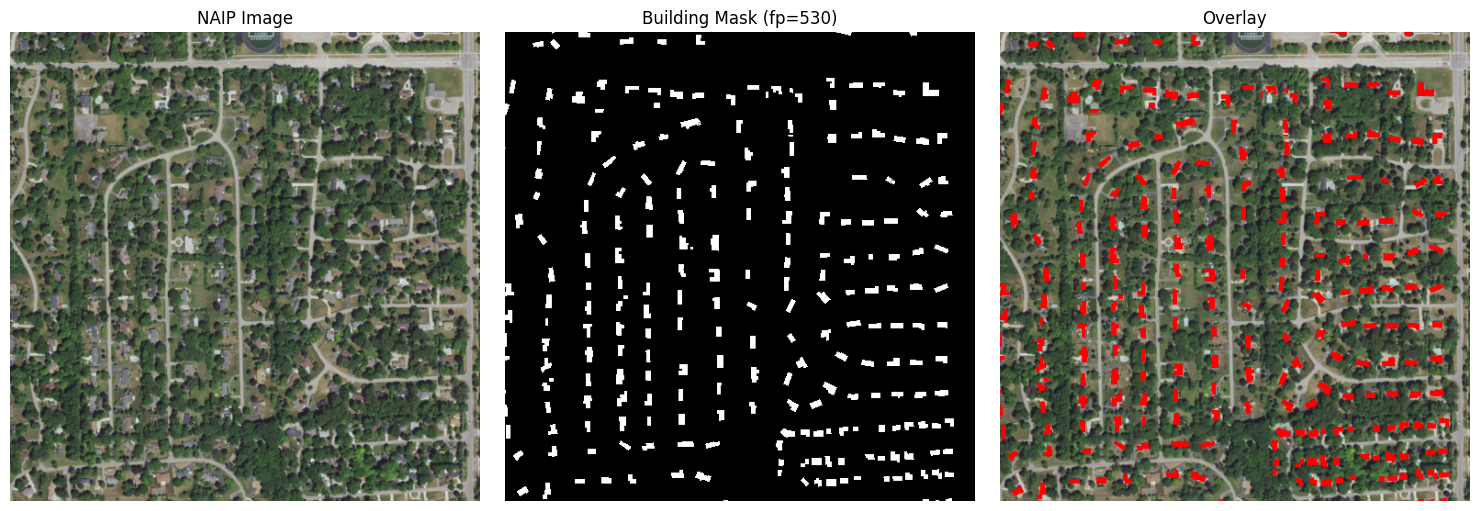

In [ ]:
print('=== Single Sample Test ===')
row  = gdf_bg.iloc[0]
bbox = row.geometry.bounds

img, href = fetch_naip_tile_and_href(bbox)
print(f'NAIP: {None if img is None else img.shape}')

if img is not None and href is not None:
    mask   = make_mask(ms_fp, bbox, href)
    fp_cnt = count_footprints_in_bbox(ms_fp, bbox)
    print(f'Mask shape: {mask.shape} | building pixels: {mask.sum()}')
    print(f'Footprint count (GT): {fp_cnt}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img);                axes[0].set_title('NAIP Image')
    axes[1].imshow(mask, cmap='gray');  axes[1].set_title(f'Building Mask (fp={fp_cnt})')
    overlay = img.copy(); overlay[mask==1] = [255, 0, 0]
    axes[2].imshow(overlay);            axes[2].set_title('Overlay')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('No NAIP found → try another block group')

## 2-5. Generate Tile Candidate List

In [ ]:
TILES_PER_COUNTY_BY_TYPE = {
    'urban'    : 3000,
    'suburban' : 2000,
    'rural'    : 500,
}

all_tiles          = []
county_tile_counts = {}
random.seed(42)

for countyfp, grp in gdf_bg.groupby('COUNTYFP'):
    ctype = grp['county_type'].iloc[0]
    cap   = TILES_PER_COUNTY_BY_TYPE[ctype]

    county_tiles = []
    for _, row in grp.iterrows():
        geoid  = row['GEOID']
        bboxes = split_bbox_into_tiles_m(row)
        for j, bbox in enumerate(bboxes):
            county_tiles.append((geoid, j, bbox, ctype))

    if len(county_tiles) > cap:
        county_tiles = random.sample(county_tiles, cap)

    all_tiles.extend(county_tiles)
    county_tile_counts[countyfp] = len(county_tiles)

random.shuffle(all_tiles)

print(f'Total tile candidates: {len(all_tiles):,}')
print(f'Target: {MAX_TILES:,}')
print()
from collections import Counter
for ctype, cnt in sorted(Counter(t[3] for t in all_tiles).items()):
    print(f'  {ctype:10s}: {cnt:6,}')
print()
print('Tile count by county:')
for k, v in sorted(county_tile_counts.items(), key=lambda x: -x[1]):
    print(f'  {k}: {v}')

Total tile candidates: 3,000
Target: 4,000

  urban     :  3,000

Tile count by county:
  125: 3000


## 2-6. Resume: Sync Drive → Local (Run after runtime restart only)

In [ ]:
import subprocess

print('Syncing tiles from Drive to local...')
r1 = subprocess.run(['rsync', '-a', '--ignore-existing', f'{TILE_IMG_DIR}/',  f'{FAST_IMG_DIR}/'],  capture_output=True, text=True)
r2 = subprocess.run(['rsync', '-a', '--ignore-existing', f'{TILE_MASK_DIR}/', f'{FAST_MASK_DIR}/'], capture_output=True, text=True)

img_count = len(list(Path(FAST_IMG_DIR).glob('*.png')))
print(f'✓ Done | {img_count} tiles in local')

Syncing tiles from Drive to local...
✓ Done | 5818 tiles in local


## 2-7. Main Tile Generation Loop (County-Batch Mode)

In [ ]:
from collections import defaultdict

_src_cache = {}  # item_id → open rasterio src

tile_meta_rows = []
skipped = saved = errors = 0
empty_cnt = non_empty_cnt = 0

geoid_info = gdf_bg.set_index('GEOID')[[
    'COUNTYFP','TRACTCE','BLKGRPCE','NAMELSAD','area_km2','county_type'
]].to_dict('index')

county_tile_map = defaultdict(list)
for geoid, j, bbox, ctype in all_tiles:
    countyfp = geoid[:5]
    county_tile_map[countyfp].append((geoid, j, bbox, ctype))

print(f'County-batch mode | {len(county_tile_map)} counties | '
      f'{len(all_tiles):,} tile candidates | target {MAX_TILES:,}')

done = False
for county_idx, (countyfp, tiles_in_county) in enumerate(county_tile_map.items(), 1):
    if done:
        break

    county_geoids = [t[0] for t in tiles_in_county]
    county_bgs    = gdf_bg[gdf_bg['GEOID'].isin(county_geoids)]
    county_bbox   = tuple(county_bgs.total_bounds)

    print(f'\n[{county_idx}/{len(county_tile_map)}] County {countyfp} | '
          f'{len(tiles_in_county)} tiles | bbox={[round(x,3) for x in county_bbox]}')

    items = get_county_naip_items(county_bbox)
    if not items:
        print(f'  No NAIP found for county {countyfp} — skipping')
        continue
    print(f'  NAIP scenes: {len(items)}')

    candidates = list(ms_fp_sindex.intersection(county_bbox))
    fp_county  = ms_fp.iloc[candidates]
    print(f'  Footprints in county: {len(fp_county):,}')

    try:
        for geoid, j, bbox, ctype in tiles_in_county:
            if done:
                break

            tile_id  = f'{geoid}_{j}'
            img_path = f'{FAST_IMG_DIR}/{tile_id}.png'
            msk_path = f'{FAST_MASK_DIR}/{tile_id}.png'

            if os.path.exists(img_path) and os.path.exists(msk_path):
                skipped += 1
                mask_arr = np.array(Image.open(msk_path).convert('L'))
                mask_bin = (mask_arr > 127).astype(np.uint8)
                fp_stats = get_footprint_stats_in_bbox(fp_county, bbox, None)
                gi = geoid_info.get(geoid, {})
                tile_meta_rows.append({
                    'tile_id'            : tile_id,
                    'geoid'              : geoid,
                    'county_fips'        : gi.get('COUNTYFP', ''),
                    'county_type'        : gi.get('county_type', ctype),
                    'tract_ce'           : gi.get('TRACTCE', ''),
                    'blkgrp_ce'          : gi.get('BLKGRPCE', ''),
                    'tract_id'           : geoid[:11],
                    'namelsad'           : gi.get('NAMELSAD', ''),
                    'bg_area_km2'        : gi.get('area_km2', np.nan),
                    'bbox_minx'          : bbox[0],
                    'bbox_miny'          : bbox[1],
                    'bbox_maxx'          : bbox[2],
                    'bbox_maxy'          : bbox[3],
                    'footprint_count'    : fp_stats['footprint_count'],
                    'fp_area_mean_m2'    : fp_stats['fp_area_mean_m2'],
                    'fp_area_sum_m2'     : fp_stats['fp_area_sum_m2'],
                    'fp_area_max_m2'     : fp_stats['fp_area_max_m2'],
                    'mask_building_ratio': round(float(mask_bin.mean()), 5),
                    'mask_building_px'   : int(mask_bin.sum()),
                })
                if (skipped + saved) >= MAX_TILES:
                    print(f'\n★ Target {MAX_TILES:,} reached → stopping')
                    done = True
                continue

            src = get_fresh_src(items, bbox)
            if src is None:
                continue

            try:
                img = slice_tile_from_open_src(src, bbox)
                if img is None:
                    continue

                mask     = make_mask_from_open_src(src, fp_county, bbox)
                is_empty = (mask.sum() == 0)
                fp_stats = get_footprint_stats_in_bbox(fp_county, bbox, None)

                if is_empty:
                    empty_cnt += 1
                else:
                    non_empty_cnt += 1

                Image.fromarray(img).save(img_path)
                Image.fromarray((mask * 255).astype(np.uint8)).save(msk_path)
                saved += 1

                gi = geoid_info.get(geoid, {})
                tile_meta_rows.append({
                    'tile_id'            : tile_id,
                    'geoid'              : geoid,
                    'county_fips'        : gi.get('COUNTYFP', ''),
                    'county_type'        : gi.get('county_type', ctype),
                    'tract_ce'           : gi.get('TRACTCE', ''),
                    'blkgrp_ce'          : gi.get('BLKGRPCE', ''),
                    'tract_id'           : geoid[:11],
                    'namelsad'           : gi.get('NAMELSAD', ''),
                    'bg_area_km2'        : gi.get('area_km2', np.nan),
                    'bbox_minx'          : bbox[0],
                    'bbox_miny'          : bbox[1],
                    'bbox_maxx'          : bbox[2],
                    'bbox_maxy'          : bbox[3],
                    'footprint_count'    : fp_stats['footprint_count'],
                    'fp_area_mean_m2'    : fp_stats['fp_area_mean_m2'],
                    'fp_area_sum_m2'     : fp_stats['fp_area_sum_m2'],
                    'fp_area_max_m2'     : fp_stats['fp_area_max_m2'],
                    'mask_building_ratio': round(float(mask.mean()), 5),
                    'mask_building_px'   : int(mask.sum()),
                })

                if (skipped + saved) >= MAX_TILES:
                    print(f'\n★ Target {MAX_TILES:,} reached → stopping')
                    done = True

            except Exception as e:
                errors += 1
                print(f'  [tile error] {tile_id}: {repr(e)}')

            # ← src.close() 제거 (캐시에서 관리)

    finally:
        # Close and clear src cache at end of each county
        for s in _src_cache.values():
            try: s.close()
            except: pass
        _src_cache.clear()

    total_done = skipped + saved
    pct = total_done / MAX_TILES * 100
    print(f'  → county done | total {total_done:,}/{MAX_TILES:,} ({pct:.1f}%) | '
          f'new={saved} skipped={skipped} errors={errors}')

    if county_idx % 3 == 0 and tile_meta_rows:
        _df = pd.DataFrame(tile_meta_rows)
        _ckpt = f'{META_DIR}/tile_metadata_checkpoint_batchA2.csv'
        if os.path.exists(_ckpt):
            _old = pd.read_csv(_ckpt, dtype={'geoid':str,'tract_id':str})
            _df  = pd.concat([_old, _df], ignore_index=True).drop_duplicates('tile_id', keep='last')
        _df.to_csv(_ckpt, index=False)
        print(f'  [checkpoint] saved {len(_df)} rows → {_ckpt}')

print(f'\nDone!')
print(f'Newly saved : {saved:,}')
print(f'Skipped     : {skipped:,} (metadata collected)')
print(f'Errors      : {errors}')
print(f'Empty tiles : {empty_cnt:,}')
print(f'Non-empty   : {non_empty_cnt:,}')
print(f'Meta rows   : {len(tile_meta_rows):,}')

## 2-8. Save tile_metadata.csv

In [ ]:
df_meta = pd.DataFrame(tile_meta_rows)

META_CSV = f'{META_DIR}/tile_metadata.csv'
if os.path.exists(META_CSV):
    df_old  = pd.read_csv(META_CSV, dtype={'geoid': str, 'tract_id': str})
    df_meta = pd.concat([df_old, df_meta], ignore_index=True) \
                .drop_duplicates(subset='tile_id', keep='last')

df_meta.to_csv(META_CSV, index=False)
print(f'✓ tile_metadata.csv saved: {len(df_meta)} tiles')
print(f'  Columns: {df_meta.columns.tolist()}')
print()
print(df_meta[['tile_id','tract_id','namelsad',
               'footprint_count','fp_area_mean_m2',
               'mask_building_ratio']].head(10).to_string())
print()
print('=== Building Count Distribution ===')
print(df_meta['footprint_count'].describe().round(2))

✓ tile_metadata.csv saved: 6191 tiles
  Columns: ['tile_id', 'geoid', 'county_fips', 'county_type', 'tract_ce', 'blkgrp_ce', 'tract_id', 'namelsad', 'bg_area_km2', 'bbox_minx', 'bbox_miny', 'bbox_maxx', 'bbox_maxy', 'footprint_count', 'fp_area_mean_m2', 'fp_area_sum_m2', 'fp_area_max_m2', 'mask_building_ratio', 'mask_building_px', 'clean', 'reason']

              tile_id     tract_id       namelsad  footprint_count  fp_area_mean_m2  mask_building_ratio
0   260639509004_1332  26063950900  Block Group 4                0             0.00              0.00000
1  260639900000_13492  26063990000  Block Group 0                0             0.00              0.00000
2    260639506002_591  26063950600  Block Group 2                0             0.00              0.00000
3   260639509003_1315  26063950900  Block Group 3                0             0.00              0.00000
4    260639509003_606  26063950900  Block Group 3                0             0.00              0.00000
5  260639900000_1

## 2-9. Generate tile_footprint_counts.csv

In [ ]:
FP_COUNT_CSV = f'{META_DIR}/tile_footprint_counts.csv'
df_meta[['tile_id','footprint_count']].to_csv(FP_COUNT_CSV, index=False)
print(f'✓ tile_footprint_counts.csv saved: {len(df_meta)} rows')
print(df_meta['footprint_count'].value_counts().sort_index().head(20))

✓ tile_footprint_counts.csv saved: 6191 rows
footprint_count
0     3343
1      459
2      368
3      322
4      214
5      162
6      135
7      125
8       95
9       68
10      61
11      48
12      44
13      53
14      36
15      27
16      25
17      40
18      34
19      36
Name: count, dtype: int64


## 2-10. Check Tile Distribution

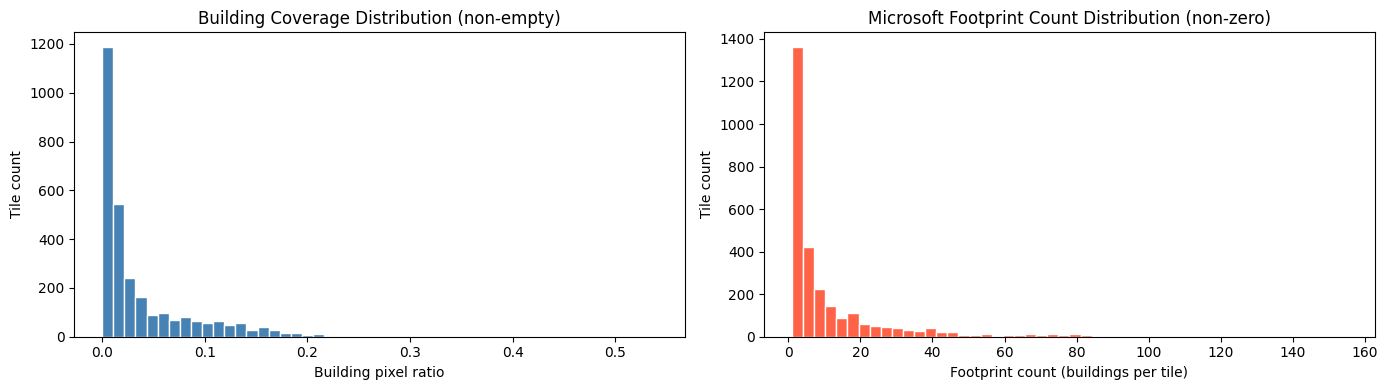

empty tiles       : 3343
non-empty tiles   : 2848
avg building/tile : 12.64
max building/tile : 155


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ratios = df_meta.loc[df_meta['mask_building_ratio'] > 0, 'mask_building_ratio']
axes[0].hist(ratios, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Building pixel ratio')
axes[0].set_ylabel('Tile count')
axes[0].set_title('Building Coverage Distribution (non-empty)')

counts = df_meta.loc[df_meta['footprint_count'] > 0, 'footprint_count']
axes[1].hist(counts, bins=50, color='tomato', edgecolor='white')
axes[1].set_xlabel('Footprint count (buildings per tile)')
axes[1].set_ylabel('Tile count')
axes[1].set_title('Microsoft Footprint Count Distribution (non-zero)')

plt.tight_layout()
plt.savefig(f'{META_DIR}/tile_distributions.png', dpi=150)
plt.show()

print(f'empty tiles       : {(df_meta["footprint_count"]==0).sum()}')
print(f'non-empty tiles   : {(df_meta["footprint_count"]>0).sum()}')
if len(counts) > 0:
    print(f'avg building/tile : {counts.mean():.2f}')
    print(f'max building/tile : {counts.max()}')

## 2-11. Build Clean Dataset

**Removal criteria:**
1. **mask_too_large** (>40%): excessive footprint coverage → suspected misalignment
2. **color_anomaly** (std<5): cloud cover or no-data pixels
3. **edge_concentration**: 80%+ of buildings within 20px of image border

In [ ]:
def check_tile_quality(img_path, mask_path):
    img      = np.array(Image.open(img_path).convert('RGB'))
    mask_arr = np.array(Image.open(mask_path).convert('L'))
    mask_bin = (mask_arr > 127).astype(np.uint8)
    ratio    = mask_bin.mean()

    if ratio > 0.40:
        return False, 'mask_too_large'
    if img.std() < 5.0:
        return False, 'color_anomaly'
    if ratio > 0.005:
        H, W   = mask_bin.shape
        border = 20
        edge   = np.zeros_like(mask_bin)
        edge[:border,:]=1; edge[-border:,:]=1
        edge[:,:border]=1; edge[:,-border:]=1
        if (mask_bin*edge).sum() / (mask_bin.sum()+1e-6) > 0.8:
            return False, 'edge_concentration'
    return True, 'ok'

all_imgs = sorted(Path(FAST_IMG_DIR).glob('*.png'))
print(f'Quality check: {len(all_imgs)} tiles')

qc_rows = []
for p in all_imgs:
    msk_p = Path(FAST_MASK_DIR) / p.name
    if not msk_p.exists(): continue
    ok, reason = check_tile_quality(str(p), str(msk_p))
    qc_rows.append({'tile_id': p.stem, 'clean': ok, 'reason': reason})

df_quality = pd.DataFrame(qc_rows)
print(df_quality['reason'].value_counts().to_string())
print(f'\nClean tiles: {df_quality["clean"].sum()} / {len(df_quality)}')

Quality check: 6157 tiles
reason
ok                6156
mask_too_large       1

Clean tiles: 6156 / 6157


## 2-11-1. Visualize Rejected Tiles (Review Before Removal)


[mask_too_large] 1 tiles


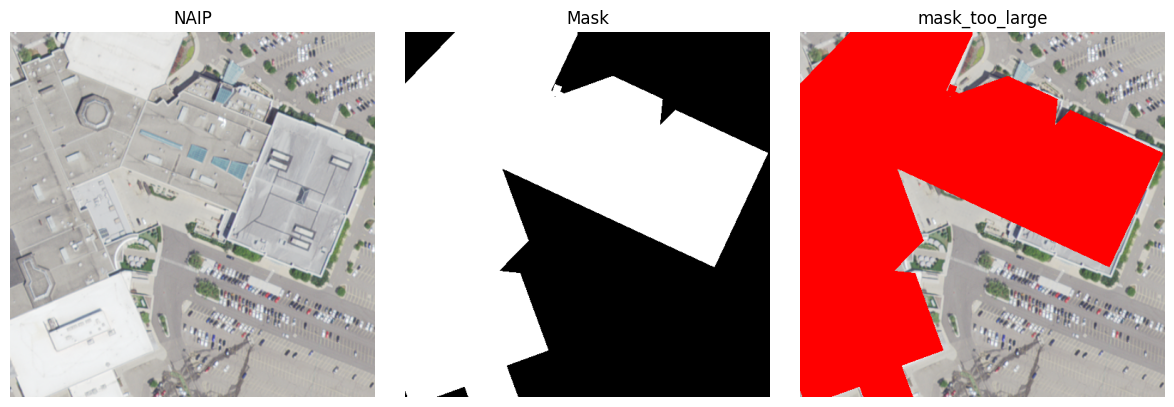

In [ ]:
for reason in df_quality[df_quality['clean']==False]['reason'].unique():
    bad_ids = df_quality[(df_quality['clean']==False)&(df_quality['reason']==reason)]['tile_id'].tolist()
    sample  = random.sample(bad_ids, min(2, len(bad_ids)))
    print(f'\n[{reason}] {len(bad_ids)} tiles')
    fig, axes = plt.subplots(len(sample), 3, figsize=(12, 4*len(sample)))
    if len(sample)==1: axes=[axes]
    for i, tid in enumerate(sample):
        img  = np.array(Image.open(f'{FAST_IMG_DIR}/{tid}.png').convert('RGB'))
        mask = np.array(Image.open(f'{FAST_MASK_DIR}/{tid}.png').convert('L'))
        ov   = img.copy(); ov[mask>127]=[255,0,0]
        axes[i][0].imshow(img);             axes[i][0].set_title('NAIP')
        axes[i][1].imshow(mask>127,cmap='gray'); axes[i][1].set_title('Mask')
        axes[i][2].imshow(ov);              axes[i][2].set_title(f'{reason}')
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout(); plt.show()

## 2-11-2. Finalize Clean Dataset + Apply QC Flags

In [ ]:
CLEAN_IMG_DIR  = f'{FAST_BASE}/clean/images'
CLEAN_MASK_DIR = f'{FAST_BASE}/clean/masks'
os.makedirs(CLEAN_IMG_DIR,  exist_ok=True)
os.makedirs(CLEAN_MASK_DIR, exist_ok=True)

clean_ids = df_quality[df_quality['clean']==True]['tile_id'].tolist()
for tid in clean_ids:
    shutil.copy2(f'{FAST_IMG_DIR}/{tid}.png', f'{CLEAN_IMG_DIR}/{tid}.png')
    shutil.copy2(f'{FAST_MASK_DIR}/{tid}.png',f'{CLEAN_MASK_DIR}/{tid}.png')

df_quality.to_csv(f'{META_DIR}/tile_quality.csv', index=False)

df_meta = pd.read_csv(f'{META_DIR}/tile_metadata.csv', dtype={'geoid':str,'tract_id':str})

for col in ['clean', 'reason']:
    if col in df_meta.columns:
        df_meta = df_meta.drop(columns=[col])

df_meta = df_meta.merge(df_quality[['tile_id','clean','reason']], on='tile_id', how='left')
df_meta['clean']  = df_meta['clean'].fillna(False)
df_meta['reason'] = df_meta['reason'].fillna('not_generated')
df_meta.to_csv(f'{META_DIR}/tile_metadata.csv', index=False)

df_fp_clean = df_meta[df_meta['clean']==True][['tile_id','footprint_count']]
df_fp_clean.to_csv(f'{META_DIR}/tile_footprint_counts.csv', index=False)

print(f'Clean tiles: {len(clean_ids)}')
print(f'Removed tiles: {len(df_quality) - len(clean_ids)}')
print(f'tile_footprint_counts.csv (clean only): {len(df_fp_clean)} rows')

FAST_IMG_DIR  = CLEAN_IMG_DIR
FAST_MASK_DIR = CLEAN_MASK_DIR
print('\nFAST_IMG_DIR / FAST_MASK_DIR → updated to clean folder')

Clean tiles: 6156
Removed tiles: 1
tile_footprint_counts.csv (clean only): 6156 rows

FAST_IMG_DIR / FAST_MASK_DIR → updated to clean folder


## 2-12. Visualize Clean Samples

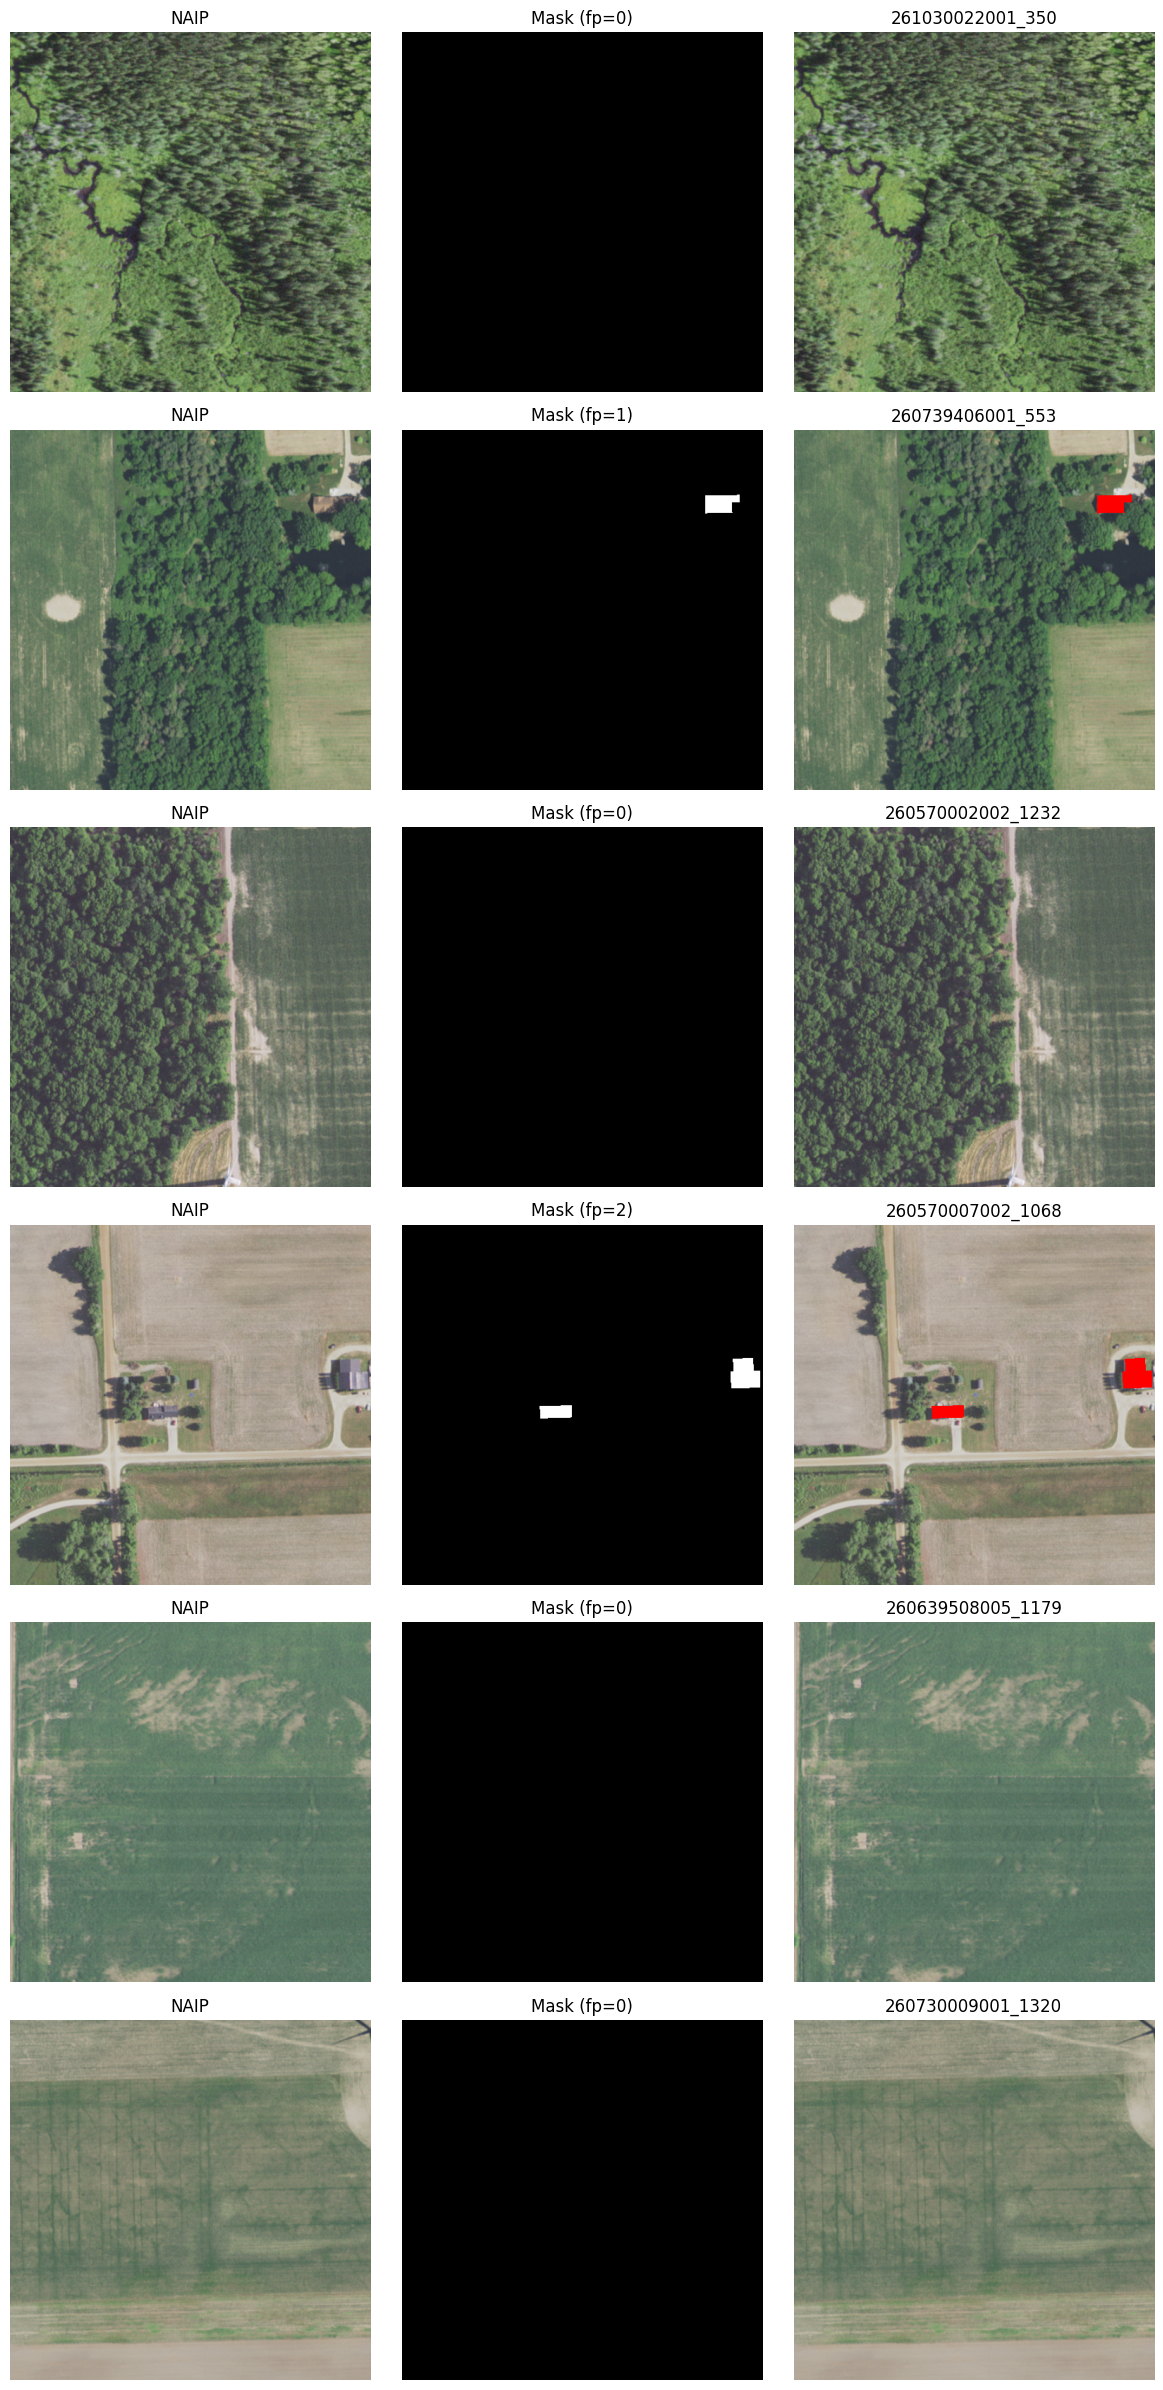

In [ ]:
fp_map = df_meta.set_index('tile_id')['footprint_count'].to_dict()

clean_sample = random.sample(clean_ids, min(6, len(clean_ids)))
fig, axes    = plt.subplots(len(clean_sample), 3, figsize=(12, 4*len(clean_sample)))
if len(clean_sample)==1: axes=[axes]

for i, tid in enumerate(clean_sample):
    img  = np.array(Image.open(f'{FAST_IMG_DIR}/{tid}.png').convert('RGB'))
    mask = np.array(Image.open(f'{FAST_MASK_DIR}/{tid}.png').convert('L'))
    ov   = img.copy(); ov[mask>127]=[255,0,0]
    fp_c = fp_map.get(tid, '?')
    axes[i][0].imshow(img);             axes[i][0].set_title('NAIP')
    axes[i][1].imshow(mask>127,cmap='gray'); axes[i][1].set_title(f'Mask (fp={fp_c})')
    axes[i][2].imshow(ov);              axes[i][2].set_title(f'{tid}')
    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig(f'{META_DIR}/clean_sample_overlay.png', dpi=100)
plt.show()

## 2-13. Save Train/Val Split

In [ ]:
img_ids = {p.stem for p in Path(FAST_IMG_DIR).glob('*.png')}
msk_ids = {p.stem for p in Path(FAST_MASK_DIR).glob('*.png')}
all_ids = sorted(img_ids & msk_ids)

random.seed(42)
random.shuffle(all_ids)
n_train   = int(len(all_ids) * 0.8)
train_ids = all_ids[:n_train]
val_ids   = all_ids[n_train:]

pd.Series(train_ids).to_csv(f'{META_DIR}/train_ids.csv', index=False, header=False)
pd.Series(val_ids).to_csv(f'{META_DIR}/val_ids.csv',   index=False, header=False)

print(f'Usable pairs: {len(all_ids)}')
print(f'Train: {len(train_ids)} | Val: {len(val_ids)}')

df_train = df_meta[df_meta['tile_id'].isin(train_ids)]
df_val   = df_meta[df_meta['tile_id'].isin(val_ids)]
print(f'\nTrain footprint count: mean={df_train["footprint_count"].mean():.2f}')
print(f'Val   footprint count: mean={df_val["footprint_count"].mean():.2f}')

Usable pairs: 6156
Train: 4924 | Val: 1232

Train footprint count: mean=5.73
Val   footprint count: mean=5.78


## 2-14. Copy to Drive (Final Save)

In [ ]:
Path(TILE_IMG_DIR).mkdir(parents=True, exist_ok=True)
Path(TILE_MASK_DIR).mkdir(parents=True, exist_ok=True)

img_files = os.listdir(FAST_IMG_DIR)
print(f'Copying to Drive: {len(img_files)} tiles')

for i, fname in enumerate(img_files):
    shutil.copy2(f'{FAST_IMG_DIR}/{fname}',  f'{TILE_IMG_DIR}/{fname}')
    shutil.copy2(f'{FAST_MASK_DIR}/{fname}', f'{TILE_MASK_DIR}/{fname}')
    if (i+1) % 200 == 0:
        print(f'  {i+1}/{len(img_files)} done')

for csv_name in ['tile_metadata.csv', 'tile_footprint_counts.csv',
                 'tile_quality.csv', 'train_ids.csv', 'val_ids.csv']:
    src = f'{META_DIR}/{csv_name}'
    dst = f'{BASE_DIR}/metadata/{csv_name}'
    if os.path.exists(src) and os.path.realpath(src) != os.path.realpath(dst):
        shutil.copy2(src, dst)

Copying to Drive: 6156 tiles
  200/6156 done
  400/6156 done
  600/6156 done
  800/6156 done
  1000/6156 done
  1200/6156 done
  1400/6156 done
  1600/6156 done
  1800/6156 done
  2000/6156 done
  2200/6156 done
  2400/6156 done
  2600/6156 done
  2800/6156 done
  3000/6156 done
  3200/6156 done
  3400/6156 done
  3600/6156 done
  3800/6156 done
  4000/6156 done
  4200/6156 done
  4400/6156 done
  4600/6156 done
  4800/6156 done
  5000/6156 done
  5200/6156 done
  5400/6156 done
  5600/6156 done
  5800/6156 done
  6000/6156 done


## 2-15. Final Summary

In [ ]:
df_meta  = pd.read_csv(f'{META_DIR}/tile_metadata.csv', dtype={'geoid':str,'tract_id':str})
df_clean = df_meta[df_meta['clean']==True]

print('='*55)
print('Phase 1 & 2 Completion Summary — Batch A')
print('='*55)
print(f'Total tiles           : {len(df_meta)}')
print(f'Clean tiles           : {len(df_clean)}')
print(f'Train / Val           : {len(train_ids)} / {len(val_ids)}')
print()
print('[Building Count Labels — Microsoft Footprint]')
print(f'  0-building tiles (empty)    : {(df_clean["footprint_count"]==0).sum()}')
print(f'  1~5 building tiles          : {((df_clean["footprint_count"]>=1)&(df_clean["footprint_count"]<=5)).sum()}')
print(f'  6~20 building tiles         : {((df_clean["footprint_count"]>=6)&(df_clean["footprint_count"]<=20)).sum()}')
print(f'  21+ building tiles (dense)  : {(df_clean["footprint_count"]>=21).sum()}')
print(f'  Mean buildings/tile         : {df_clean["footprint_count"].mean():.2f}')
print()
print('[Output Files]')
print(f'  tile_metadata.csv           → {META_DIR}')
print(f'  tile_footprint_counts.csv   → {META_DIR}')
print(f'  tile_quality.csv            → {META_DIR}')
print(f'  train_ids.csv / val_ids.csv → {META_DIR}')

Phase 1 & 2 Completion Summary — Batch A
Total tiles           : 6191
Clean tiles           : 6156
Train / Val           : 4924 / 1232

[Building Count Labels — Microsoft Footprint]
  0-building tiles (empty)    : 3331
  1~5 building tiles          : 1517
  6~20 building tiles         : 842
  21+ building tiles (dense)  : 466
  Mean buildings/tile         : 5.74

[Output Files]
  tile_metadata.csv           → /content/drive/MyDrive/michigan_unet_project/metadata
  tile_footprint_counts.csv   → /content/drive/MyDrive/michigan_unet_project/metadata
  tile_quality.csv            → /content/drive/MyDrive/michigan_unet_project/metadata
  train_ids.csv / val_ids.csv → /content/drive/MyDrive/michigan_unet_project/metadata
